<a href="https://colab.research.google.com/github/mrunalsamrutwar/ML_Models/blob/main/ML_TAE_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SVM Support Vector Machine

Aim: To build and evaluate a Support Vector Machine (SVM) model for irrigation prediction and analyze decision boundaries.

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_Dataset/smart_irrigation_dataset1.csv"
df=pd.read_csv(path)
df.head(5)

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation
0,32.57,74.89,39.76,8.73,0
1,39.66,20.05,62.95,2.63,0
2,27.28,80.13,16.00,0.32,1
3,34.55,52.32,45.56,14.21,0
4,24.92,50.13,26.45,8.21,0


In [4]:
df.describe()

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,27.561700,60.191187,42.398653,10.141427,0.078000
std,7.237384,22.977413,21.429685,5.836865,0.268261
min,15.010000,20.050000,5.020000,0.010000,0.000000
25%,21.547500,40.452500,24.170000,5.047500,0.000000
50%,27.395000,60.695000,41.845000,10.230000,0.000000
75%,33.992500,79.645000,60.922500,15.315000,0.000000
max,39.980000,99.930000,79.980000,19.990000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    1500 non-null   float64
 1   Humidity       1500 non-null   float64
 2   Soil_Moisture  1500 non-null   float64
 3   Rainfall       1500 non-null   float64
 4   Irrigation     1500 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.7 KB


In [6]:
df.shape

(1500, 5)

In [7]:
df.columns

Index(['Temperature', 'Humidity', 'Soil_Moisture', 'Rainfall', 'Irrigation'], dtype='object')

In [8]:
df.isnull().sum()
df.isnull().any().any()
df[df.isnull().any(axis=1)]

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation


In [9]:
before_rows=df.shape[0]
df=df.dropna()
after_rows=df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("Dropped rows:", before_rows - after_rows)

Before rows: 1500
After rows: 1500
Dropped rows: 0


In [10]:
clean_data = df.copy()
clean_data.columns
clean_data.shape

(1500, 5)

In [11]:
X = clean_data.iloc[:,:-1]
y = clean_data.iloc[:,-1]

print(X)
print(y)

      Temperature  Humidity  Soil_Moisture  Rainfall
0           32.57     74.89          39.76      8.73
1           39.66     20.05          62.95      2.63
2           27.28     80.13          16.00      0.32
3           34.55     52.32          45.56     14.21
4           24.92     50.13          26.45      8.21
...           ...       ...            ...       ...
1495        33.50     69.60          35.67      6.57
1496        36.66     50.69          51.16      8.87
1497        38.91     35.98          70.58     17.06
1498        39.15     75.90          34.62      2.59
1499        23.40     43.66          57.73     10.79

[1500 rows x 4 columns]
0       0
1       0
2       1
3       0
4       0
       ..
1495    0
1496    0
1497    0
1498    0
1499    0
Name: Irrigation, Length: 1500, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [15]:
y_pred = svm_model.predict(X_test)
y_pred


array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[404   6]
 [  7  33]]
Accuracy: 0.9711111111111111
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       410
           1       0.85      0.82      0.84        40

    accuracy                           0.97       450
   macro avg       0.91      0.91      0.91       450
weighted avg       0.97      0.97      0.97       450



In [17]:
probs = svm_model.predict_proba(X_test[:10])
print("Prediction Probabilities:\n", probs)

Prediction Probabilities:
 [[9.99871797e-01 1.28203351e-04]
 [9.99944957e-01 5.50434454e-05]
 [9.98181431e-01 1.81856866e-03]
 [9.99956476e-01 4.35239042e-05]
 [9.99642800e-01 3.57199975e-04]
 [5.85517541e-02 9.41448246e-01]
 [9.99980329e-01 1.96706429e-05]
 [9.97763851e-01 2.23614857e-03]
 [9.95108467e-01 4.89153304e-03]
 [9.99942343e-01 5.76572786e-05]]


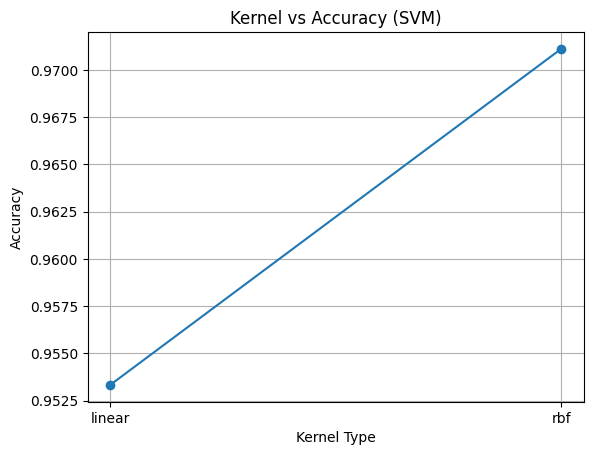

In [18]:
import matplotlib.pyplot as plt

kernels = ['linear', 'rbf']
accuracy_values = []

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    accuracy_values.append(acc)

plt.figure()
plt.plot(kernels, accuracy_values, marker='o')

plt.title("Kernel vs Accuracy (SVM)")
plt.xlabel("Kernel Type")
plt.ylabel("Accuracy")

plt.grid()
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9711111111111111
Precision: 0.8461538461538461
Recall: 0.825
F1 Score: 0.8354430379746836
